# 🌍 Economic Inequality Classification System
### Professional Machine Learning Pipeline for Streamlit Deployment

## 📌 Import Libraries

In [1]:
# ============================================================
# 📌 IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import pickle


## 📌 Load Dataset

In [2]:
# ============================================================
# 📌 LOAD DATASET
# ============================================================

df = pd.read_csv("../dataset/global_poverty_economic_inequality.csv")

# Remove hidden spaces from column names
df.columns = df.columns.str.strip()

print("✅ Dataset Loaded Successfully!")
df.head()


✅ Dataset Loaded Successfully!


,record_id,year,country,region,income_group,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
0,POV0000001,2017,Bangladesh,South Asia,Lower-Middle Income,2985,23.19,39.22,0.692,5.46,...,86.1,60.7,13.3,40.0,46.5,10.5,58.4,5.8,124,1.78
1,POV0000002,2017,Cambodia,Southeast Asia,Lower-Middle Income,1651,36.72,34.04,0.690,7.01,...,85.1,39.9,44.8,43.1,47.9,17.7,34.4,12.8,28,1.49
2,POV0000003,2019,Tanzania,Sub-Saharan Africa,Low Income,1396,72.25,40.07,0.515,5.13,...,54.0,30.6,74.9,14.0,27.0,8.0,37.7,15.5,257,0.54
3,POV0000004,2022,Myanmar,Southeast Asia,Lower-Middle Income,1304,14.46,36.31,0.661,11.96,...,71.7,34.0,59.8,44.7,55.0,16.8,44.4,7.8,196,1.00
4,POV0000005,2017,Tanzania,Sub-Saharan Africa,Low Income,1290,41.03,44.10,0.412,6.98,...,55.2,10.5,54.3,24.7,45.2,15.6,25.5,24.6,946,0.49


## 📌 Data Exploration

In [3]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Column Names
print("\nColumns:\n", df.columns.tolist())

# Dataset Info
print("\nDataset Information:")
df.info()


Dataset Shape: (10000, 25)

Columns:
 ['record_id', 'year', 'country', 'region', 'income_group', 'gdp_per_capita_usd', 'poverty_rate_pct', 'gini_coefficient', 'hdi_score', 'unemployment_rate_pct', 'inflation_rate_pct', 'literacy_rate_pct', 'life_expectancy_years', 'child_mortality_per_1000', 'electricity_access_pct', 'clean_water_access_pct', 'internet_penetration_pct', 'female_labor_participation_pct', 'social_protection_coverage_pct', 'income_share_top10_pct', 'income_share_bottom40_pct', 'urban_population_pct', 'remittances_pct_of_gdp', 'foreign_aid_million_usd', 'co2_per_capita_tonnes']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       10000 non-null  object 
 1   year                            10000 non-null  int64  
 2   country                

In [4]:
# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

record_id                         0
year                              0
country                           0
region                            0
income_group                      0
gdp_per_capita_usd                0
poverty_rate_pct                  0
gini_coefficient                  0
hdi_score                         0
unemployment_rate_pct             0
inflation_rate_pct                0
literacy_rate_pct                 0
life_expectancy_years             0
child_mortality_per_1000          0
electricity_access_pct            0
clean_water_access_pct            0
internet_penetration_pct          0
female_labor_participation_pct    0
social_protection_coverage_pct    0
income_share_top10_pct            0
income_share_bottom40_pct         0
urban_population_pct              0
remittances_pct_of_gdp            0
foreign_aid_million_usd           0
co2_per_capita_tonnes             0
dtype: int64


In [5]:
# Statistical Summary
df.describe()


,year,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,inflation_rate_pct,literacy_rate_pct,life_expectancy_years,child_mortality_per_1000,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2020.113500,13365.287600,22.881256,42.139246,0.656249,8.965726,10.112306,73.955290,69.55495,36.769500,...,74.716140,54.824540,53.164850,39.502570,40.017980,14.993200,52.265010,7.052740,159.121800,3.901968
std,2.708865,22003.606806,20.620316,7.628379,0.162896,3.770972,8.062916,17.789112,8.34909,31.345278,...,19.550464,25.822714,16.765984,23.854333,8.656358,4.040707,21.662953,6.383465,295.693218,4.601258
min,2015.000000,470.000000,0.500000,20.300000,0.352000,-1.020000,-2.910000,35.100000,52.00000,1.500000,...,30.000000,5.000000,5.500000,5.000000,25.000000,8.000000,15.000000,0.000000,0.000000,0.100000
25%,2018.000000,1518.000000,4.787500,36.740000,0.535000,6.120000,4.720000,60.400000,63.80000,10.400000,...,61.700000,32.900000,44.900000,19.975000,32.500000,11.500000,34.400000,1.800000,13.000000,0.700000
50%,2020.000000,2920.000000,16.980000,42.075000,0.649000,8.640000,8.160000,74.900000,69.50000,29.400000,...,78.900000,53.600000,58.000000,35.300000,40.200000,15.000000,50.000000,4.800000,61.000000,2.140000
75%,2022.000000,11478.250000,35.692500,47.912500,0.759000,11.530000,11.870000,89.800000,75.70000,53.500000,...,91.200000,74.400000,65.900000,57.000000,47.500000,18.500000,71.500000,11.400000,176.000000,5.530000
max,2024.000000,107221.000000,74.870000,63.510000,0.990000,21.310000,38.770000,99.900000,86.30000,119.700000,...,100.000000,99.000000,83.200000,95.000000,55.000000,22.000000,95.000000,25.000000,6213.000000,19.980000


## 📌 Handle Missing Values

In [6]:
# ============================================================
# 📌 HANDLE MISSING VALUES
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("✅ Missing Values Handled")


✅ Missing Values Handled


## 📌 Create Target Variable

In [7]:
# ============================================================
# 📌 CREATE POVERTY CLASSES
# ============================================================

df["Poverty_Class"] = pd.cut(
    df["poverty_rate_pct"],
    bins=[0, 30, 70, 100],
    labels=["Low", "Medium", "High"]
)

print(df["Poverty_Class"].value_counts())


Poverty_Class
Low       6617
Medium    3216
High       167
Name: count, dtype: int64


## 📌 Data Visualization

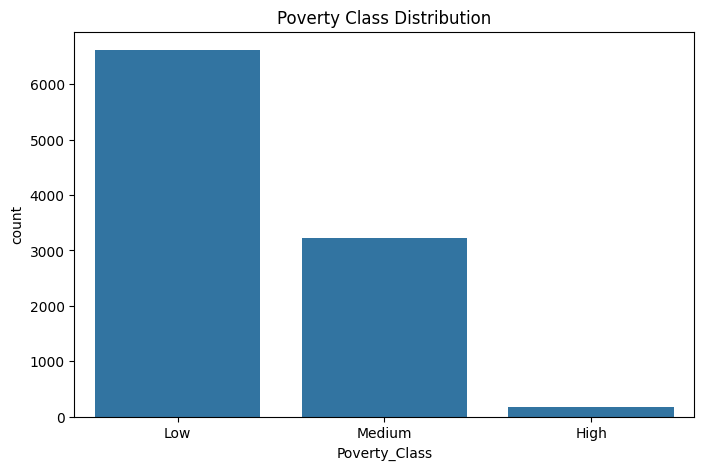

In [8]:
# Poverty Class Distribution

plt.figure(figsize=(8,5))
sns.countplot(x="Poverty_Class", data=df)
plt.title("Poverty Class Distribution")
plt.show()


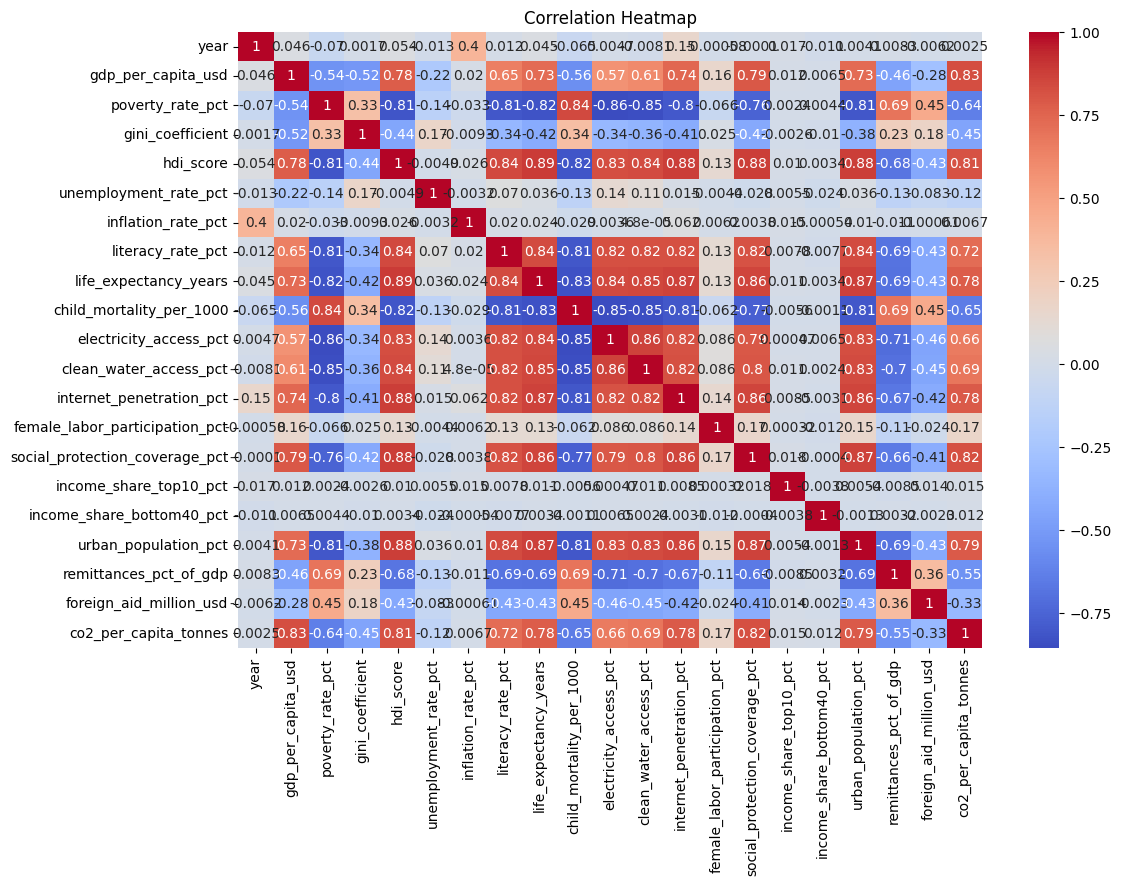

In [9]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 📌 Label Encoding

In [10]:
# ============================================================
# 📌 LABEL ENCODING
# ============================================================

categorical_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Label Encoding Completed")


✅ Label Encoding Completed


## 📌 Feature Engineering

In [11]:
# ============================================================
# 📌 FEATURE & TARGET SEPARATION
# ============================================================

X = df.drop(["poverty_rate_pct", "Poverty_Class"], axis=1)
y = df["Poverty_Class"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (10000, 24)
Target Shape: (10000,)


## 📌 Train-Test Split

In [12]:
# ============================================================
# 📌 TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Completed")


✅ Train-Test Split Completed


## 📌 Feature Scaling

In [13]:
# ============================================================
# 📌 FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Feature Scaling Completed")


✅ Feature Scaling Completed


## 📌 Handle Imbalance Using SMOTE

In [14]:
# ============================================================
# 📌 SMOTE BALANCING
# ============================================================

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied Successfully")
print(pd.Series(y_train).value_counts())


✅ SMOTE Applied Successfully
Poverty_Class
Low       5293
Medium    5293
High      5293
Name: count, dtype: int64


## 📌 Model Training

In [15]:
# ============================================================
# 📌 MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")


Logistic Regression Accuracy: 0.7845
Random Forest Accuracy: 0.8970
SVM Accuracy: 0.8595
KNN Accuracy: 0.7575
Decision Tree Accuracy: 0.8275


## 📌 Model Comparison

In [16]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
1,Random Forest,0.8970
2,SVM,0.8595
4,Decision Tree,0.8275
0,Logistic Regression,0.7845
3,KNN,0.7575


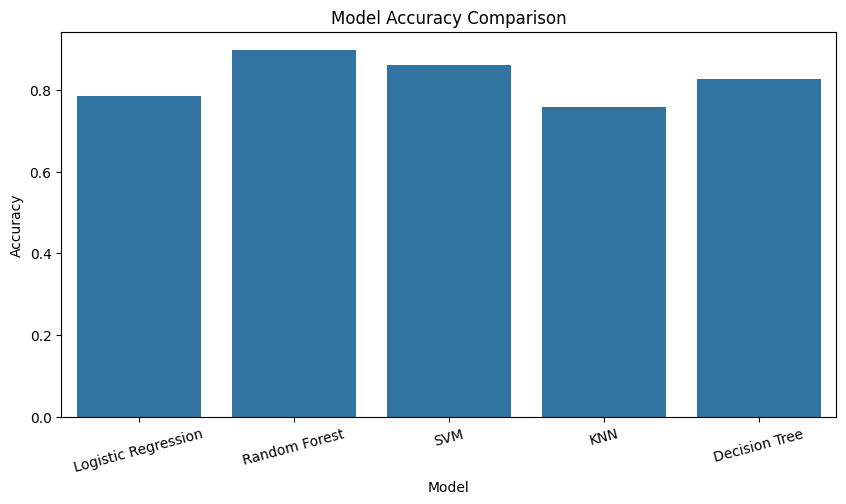

In [17]:
# Visualization

plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()


## 📌 Select Best Model

In [18]:
# ============================================================
# 📌 BEST MODEL
# ============================================================

best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

print("✅ Best Model Trained Successfully")


✅ Best Model Trained Successfully


## 📌 Model Evaluation

In [19]:
# Predictions

y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        33
         Low       0.89      0.99      0.94      1324
      Medium       0.92      0.75      0.83       643

    accuracy                           0.90      2000
   macro avg       0.61      0.58      0.59      2000
weighted avg       0.89      0.90      0.89      2000



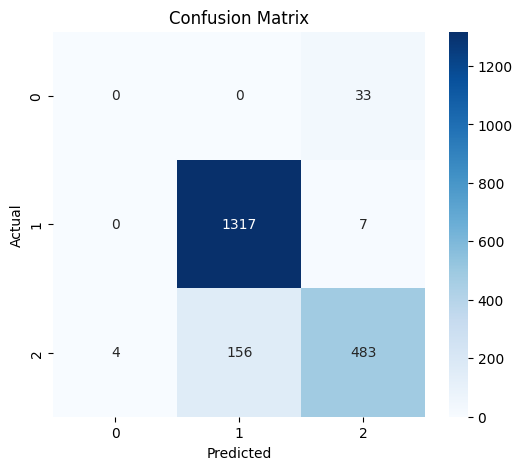

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 📌 Hyperparameter Tuning

In [21]:
# ============================================================
# 📌 GRID SEARCH
# ============================================================

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9422507714591598


## 📌 Feature Importance

In [22]:
# ============================================================
# 📌 FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)


,Feature,Importance
5,gdp_per_capita_usd,0.108615
13,electricity_access_pct,0.082291
23,co2_per_capita_tonnes,0.072687
7,hdi_score,0.061269
11,life_expectancy_years,0.059454
20,urban_population_pct,0.056692
1,year,0.054369
12,child_mortality_per_1000,0.053435
14,clean_water_access_pct,0.050164
21,remittances_pct_of_gdp,0.044654


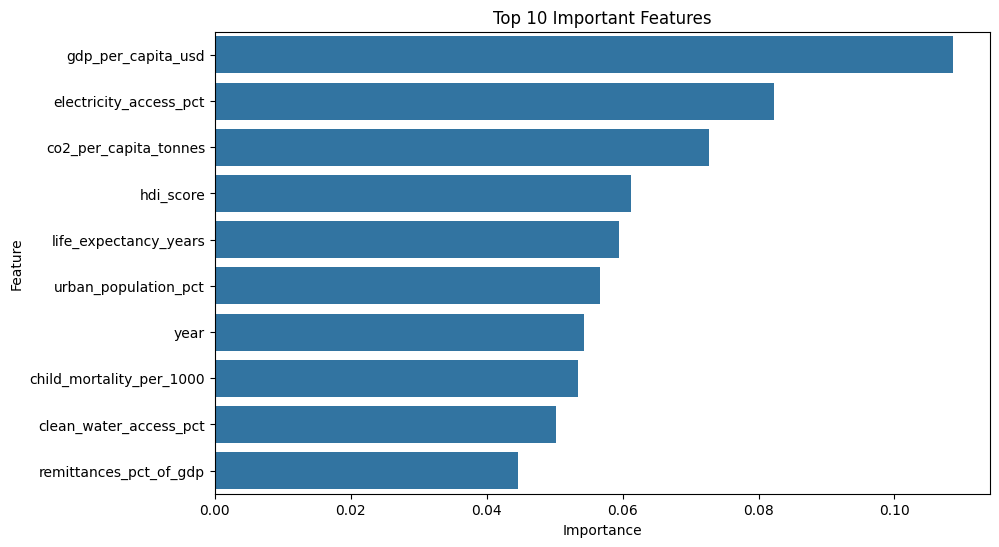

In [23]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


## 📌 Save Model & Scaler

In [24]:
# ============================================================
# 📌 SAVE MODEL
# ============================================================

with open("../models/inequality_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# ============================================================
# 📌 SAVE SCALER
# ============================================================

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model & Scaler Saved Successfully")


✅ Model & Scaler Saved Successfully


In [25]:
# ============================================================
# 📌 VERIFY SAVED FILES
# ============================================================

import os

print(
    "Model size:",
    os.path.getsize("../models/inequality_model.pkl"),
    "bytes"
)

print(
    "Scaler size:",
    os.path.getsize("../models/scaler.pkl"),
    "bytes"
)


Model size: 38962680 bytes
Scaler size: 1593 bytes


## 📊 Final Conclusion

In [26]:
print("""
🌍 Economic Inequality Classification System Completed Successfully!

✔ Data Cleaning
✔ Feature Engineering
✔ Label Encoding
✔ Feature Scaling
✔ SMOTE Balancing
✔ Multiple ML Models
✔ Hyperparameter Tuning
✔ Feature Importance
✔ Model Saving
✔ Streamlit Deployment Ready

Best Model: Random Forest Classifier
""")



🌍 Economic Inequality Classification System Completed Successfully!

✔ Data Cleaning
✔ Feature Engineering
✔ Label Encoding
✔ Feature Scaling
✔ SMOTE Balancing
✔ Multiple ML Models
✔ Hyperparameter Tuning
✔ Feature Importance
✔ Model Saving
✔ Streamlit Deployment Ready

Best Model: Random Forest Classifier

